In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
mall = pd.read_csv("mallcustomers.csv")
mall.head(10)

,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,"15,000 USD",39
1,2,Male,21,"15,000 USD",81
2,3,Female,20,"16,000 USD",6
3,4,Female,23,"16,000 USD",77
4,5,Female,31,"17,000 USD",40
5,6,Female,22,"17,000 USD",76
6,7,Female,35,"18,000 USD",6
7,8,Female,23,"18,000 USD",94
8,9,Male,64,"19,000 USD",3
9,10,Female,30,"19,000 USD",72


In [3]:
mall.dtypes

CustomerID        int64
Gender           object
Age               int64
Income           object
SpendingScore     int64
dtype: object

In [4]:
mall['Income'] = (mall['Income'].str.replace(',', '', regex=False)
                 .str.replace('USD', '', regex=False))
mall['Income'] = pd.to_numeric(mall['Income'])

In [5]:
mall.head(10)

,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,15000,39
1,2,Male,21,15000,81
2,3,Female,20,16000,6
3,4,Female,23,16000,77
4,5,Female,31,17000,40
5,6,Female,22,17000,76
6,7,Female,35,18000,6
7,8,Female,23,18000,94
8,9,Male,64,19000,3
9,10,Female,30,19000,72


In [6]:
mall = mall.drop(columns=['CustomerID'])

In [7]:
mall[['Income', 'SpendingScore']].describe()

,Income,SpendingScore
count,200.000000,200.000000
mean,60560.000000,50.200000
std,26264.721165,25.823522
min,15000.000000,1.000000
25%,41500.000000,34.750000
50%,61500.000000,50.000000
75%,78000.000000,73.000000
max,137000.000000,99.000000


In [8]:
scaler = StandardScaler()
mall[['Incomez', 'SpendingScorez']] = scaler.fit_transform(mall[['Income', 'SpendingScore']])

C:\Users\eddie\Anaconda3.1\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\eddie\Anaconda3.1\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\eddie\Anaconda3.1\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\eddie\Anaconda3.1\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^

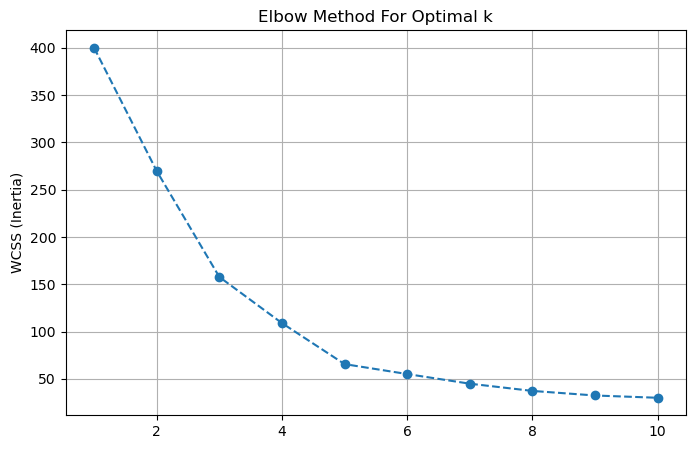

In [9]:

X = mall[['Incomez','SpendingScorez']].copy()

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o', linestyle="--")
plt.title("Elbow Method For Optimal k")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)
plt.show()

In [10]:
optimal_k = 5 

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)

kmeans.fit(X)

C:\Users\eddie\Anaconda3.1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=5, random_state=42)

In [11]:
X['clusters'] = kmeans.labels_

centroids = kmeans.cluster_centers_

print("\nCentroid Coordinates:\n", centroids)


Centroid Coordinates:
 [[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


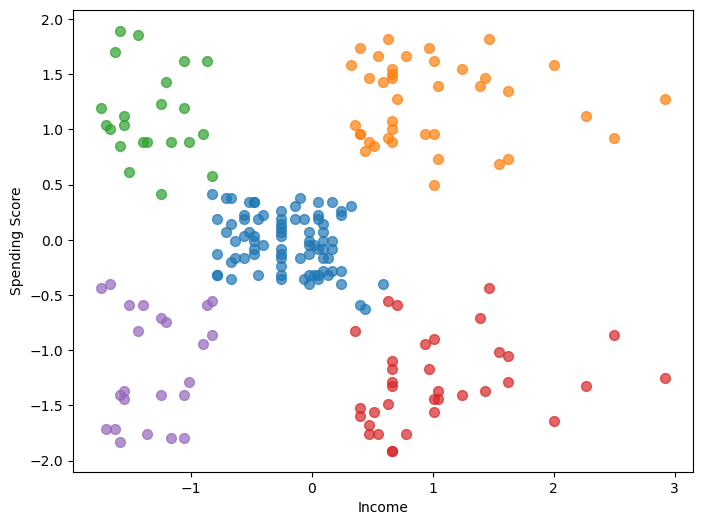

In [12]:
plt.figure(figsize=(8,6))

for cluster_id in range(optimal_k):
    cluster_data = X[X['clusters'] == cluster_id]
    plt.scatter(
        cluster_data['Incomez'],
        cluster_data['SpendingScorez'],
        label=f'Cluster {cluster_id}',
        alpha=0.7,
        s=50)
    plt.xlabel('Income')
    plt.ylabel('Spending Score')

In [13]:
gender = pd.get_dummies(mall['Gender'], dtype=int)

In [14]:
mall = pd.concat([mall, gender], axis=1)

In [15]:
mall['Cluster'] = X['clusters']

In [16]:
cluster_dem = mall.groupby('Cluster')[['Age', 'Male', 'Female']].mean()
print(cluster_dem)

               Age      Male    Female
Cluster                               
0        42.716049  0.407407  0.592593
1        32.692308  0.461538  0.538462
2        25.272727  0.409091  0.590909
3        41.114286  0.542857  0.457143
4        45.217391  0.391304  0.608696
